In [ ]:
import os
#os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
jr.init_cluster()

#parameters
nx = 32
ny = 32
nz = 32
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 1.0
t_end = 1.0
cfl_safety = 0.5 
spatial_dimensions=3
snap_path="data/engine_test_new_io"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,diss=(visc,res),hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
kgrid = jr.setup_kgrids(params)

def test_init(x,y,z):
    phi = (jnp.cos(x+1.4) + jnp.cos(y+0.5)) * jnp.sin(z)
    psi = (jnp.cos(2.0*x+2.3) + jnp.cos(y + 4.1)) * jnp.cos(z)
    return jnp.stack([phi,psi],axis=0)

state=jr.initialize(test_init,params)

nblock = jr.estimate_good_nblock(state,kgrid,params,t_snap,t_end,nblock_min=1)
print("nblock estimate: "+str(nblock))
#nblock = 1

end_state=jr.simulate_scan(state,kgrid,params,nblock,t_snap=t_snap,t_end=t_end,mngr=mngr,save=True)

jax is using 64bit precision.
nblock estimate: 88
Saving initial state as snapshot 0


In [2]:
vort=ft.irfft2(-kgrid.ksq()*end_state.fields[0,:,:,:])

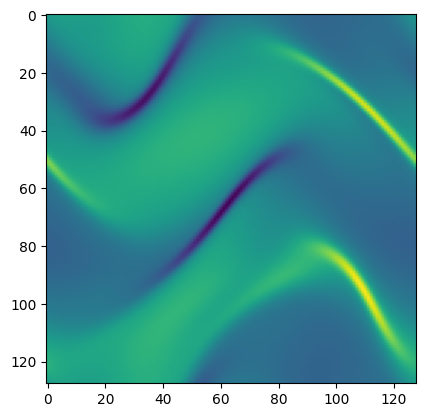

: 

In [ ]:
plt.imshow(vort[39,:,:])

In [ ]:
from jax.debug import visualize_array_sharding

# Slicing a 2D plane (index 0 of nfields, all nz, index 0 of nkx, all nky)
visualize_array_sharding(end_state.fields[:, :, 0, 0])

In [ ]:
import jax
import jax_rmhd.timestepping as ts
from functools import partial
stepper,scheme=ts.get_scheme("lsrk33")
# 1. Create a tiny test function that mirrors your real-space to k-space FFT pipeline
@partial(jax.jit,static_argnums=(2,3,4,5))
def check_hlo(state,kgrid,params,nblock,scheme,stepper):
    # This matches the rfft2 behavior on the last two axes
    return jr.run.block_of_steps(state,kgrid,params,nblock,scheme,stepper)

# 2. Lower and compile using your actual sharded array as a template
# (Assuming `sample_field` is an array already sharded with fields_sharding)
lowered = check_hlo.lower(state,kgrid,params,nblock,scheme,stepper)
compiled = lowered.compile()

# 3. Extract the text representation of XLA's optimized execution plan
hlo_text = compiled.as_text()

# 4. Search for cross-device communication operations
communication_ops = ["all-to-all", "all-gather", "reduce-scatter", "collective-permute"]
has_communication = False

print("Checking XLA HLO for cross-device communication...")
for op in communication_ops:
    if op in hlo_text.lower():
        print(f"⚠️ FOUND: {op} is happening!")
        has_communication = True

if not has_communication:
    print("✅ Success! No cross-device communication found.")

Checking XLA HLO for cross-device communication...
⚠️ FOUND: collective-permute is happening!


In [ ]:
# Assuming hlo_text is what you captured from `compiled.as_text()`
lines = hlo_text.split('\n')

print("=== TARGETED HLO COMM ANALYSIS ===")
for i, line in enumerate(lines):
    # Highlight cross-device operations
    if any(op in line for op in ["all-gather", "all-to-all", "collective-permute"]):
        print(f"\n[LINE {i}] 通信発生 (COMMUNICATION EVENT):")
        
        # Print a 3-line window BEFORE the communication to see what triggered it
        for j in range(max(0, i-3), i):
            print(f"  (Pre-op)  {lines[j].strip()}")
            
        print(f"  👉 💥 {line.strip()}")
        
        # Print a 3-line window AFTER the communication to see where data went
        for j in range(i+1, min(len(lines), i+4)):
            print(f"  (Post-op) {lines[j].strip()}")

=== TARGETED HLO COMM ANALYSIS ===

[LINE 602] 通信発生 (COMMUNICATION EVENT):
  (Pre-op)  %wrapped_slice.5 = c128[2,1,128,65]{3,2,1,0} fusion(%get-tuple-element.82), kind=kLoop, calls=%wrapped_slice_computation.5, metadata={op_name="jit(check_hlo)/while/body/closed_call/while/body/closed_call/cond/branch_0_fun/jit(_roll_static)/concatenate" stack_frame_id=196}, backend_config={"outer_dimension_partitions":["2"]}
  (Pre-op)  %wrapped_slice.4 = c128[2,2,128,65]{3,2,1,0} fusion(%get-tuple-element.82), kind=kLoop, calls=%wrapped_slice_computation.4, metadata={op_name="jit(check_hlo)/while/body/closed_call/while/body/closed_call/cond/branch_0_fun/jit(_roll_static)/concatenate" stack_frame_id=198}, backend_config={"outer_dimension_partitions":["2","1"]}
  (Pre-op)  %bitcast_concatenate_fusion.1 = c128[4,2,32,128,65]{4,3,2,1,0} fusion(%bitcast_concatenate_fusion.2, %get-tuple-element.81, %get-tuple-element.80), kind=kLoop, calls=%fused_computation.6, metadata={op_name="jit(check_hlo)/while/body/

In [3]:
import orbax.checkpoint as ocp

In [4]:
ckptr=ocp.StandardCheckpointer()

In [13]:
ckpt_path=os.path.abspath(snap_path)
p=ckpt_path +"/"+str(999)
ckptr.save(p,end_state)

In [14]:
a=ckptr.restore(p)

In [17]:
end_state

SimulationState(t=Array(10.085685, dtype=float64), fields=Array([[[[-4.65735620e-014+0.00000000e+000j,
           7.91171597e+002-8.73473616e+002j,
           1.45675440e+002+2.03585009e+002j, ...,
          -1.22432222e-264-3.90393630e-264j,
          -1.13492738e-287-9.90942605e-288j,
           0.00000000e+000+0.00000000e+000j],
         [-3.46761150e+002-1.14080349e+002j,
          -3.24033508e+002-3.27795546e+001j,
          -9.14783432e+002+1.24978888e+002j, ...,
           1.25872356e-264+1.35470671e-265j,
          -7.57184506e-289-8.31818043e-289j,
           0.00000000e+000+0.00000000e+000j],
         [ 1.20896312e+002-1.07270273e+002j,
           9.35780327e+001-2.60632921e+002j,
          -1.20136454e+002+2.57616549e+002j, ...,
          -7.86009725e-266-2.72454054e-265j,
           1.24693460e-289-6.10148409e-290j,
           0.00000000e+000+0.00000000e+000j],
         ...,
         [-2.73344412e+002-1.90249494e+002j,
           3.67872234e-001-2.12127168e-001j,
          

In [18]:
options = ocp.CheckpointManagerOptions()

In [20]:
cpath=os.path.abspath(snap_path)

with ocp.CheckpointManager(
  ocp.test_utils.erase_and_create_empty(cpath),
  options=options,
) as mn:
    mn.save(0,args=ocp.args.StandardSave(end_state))

In [2]:
import jax_rmhd.snapshot_io as sn

s=sn.load_snapshot(1,mngr,params)

TypeError: Transform.__init__() got an unexpected keyword argument 'sharding'

In [4]:
import orbax.checkpoint as ocp; help(ocp.Transform)

Help on class Transform in module orbax.checkpoint.transform_utils:

class Transform(builtins.object)
 |  Transform(original_key: Union[str, Tuple[str], NoneType] = None, use_fallback: bool = False, value_fn: Optional[Callable[[Any], Any]] = None, multi_value_fn: Optional[Callable[[str, Any], Any]] = None) -> None
 |  
 |  A representation of a transformation applied to pytree keys/values.
 |  
 |  See `apply_transformations` for usage examples. Transform represents an
 |  operation on a single key/value pair. For example, the following mapping::
 |  
 |    {'a': Transform(original_key='b')}
 |  
 |  This denotes that the original key was named 'b', but we are changing it to
 |  'a'. A regex can also be used as follows::
 |  
 |    {r'(.*)a(.*)': Transform(original_key=r'\1b\2'}
 |  
 |  This denotes that the key 'b' should be renamed to 'a'. This may apply to
 |  multiple different keys at different levels of nesting. The '/' character
 |  denotes a successive level of nesting.
 |  
 